In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygame.examples.midi import output_main
from scipy.stats import exponweib_gen

# przełączyć, jeśli nie działa
# from bitalg.visualizer.main import Visualizer
from visualizer.main import Visualizer

In [3]:
def draw_mesh(vertices, triangles):
    vis = Visualizer()
    line_segments = []

    for a, b, c in triangles:
        line_segments.append((vertices[a], vertices[b]))
        line_segments.append((vertices[b], vertices[c]))
        line_segments.append((vertices[c], vertices[a]))

    vis.add_line_segment(line_segments)
    vis.add_point(vertices, color='red')
    
    vis.show()

In [4]:
# Wierzchołki (x, y) — indeksy 0..6
points = [
    (0.0, 0.0),  # 0
    (1.0, 0.0),  # 1
    (2.0, 0.0),  # 2
    (0.0, 1.0),  # 3
    (1.0, 1.0),  # 4
    (2.0, 1.0),  # 5
    (1.0, 2.0),  # 6
]

# Trójkąty (a, b, c) — indeksy wierzchołków, CCW
triangles = [
    (0, 1, 4),
    (0, 4, 3),
    (1, 2, 5),
    (1, 5, 4),
    (3, 4, 6),
    (4, 5, 6),
]

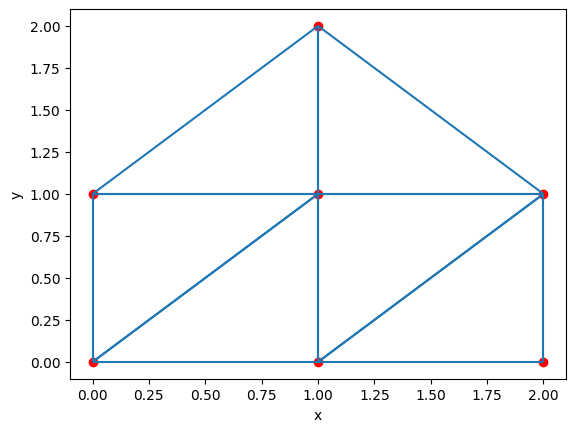

In [5]:
draw_mesh(points, triangles)

In [149]:
def save_mesh(file_path, points, indices):
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(f"{len(points)}\n")
        f.write(f"{len(indices)}\n")

        for x, y in points:
            f.write(f"{x} {y}\n")

        for a, b, c in indices:
            f.write(f"{a} {b} {c}\n")

In [6]:
def load_mesh(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        n = int(f.readline().strip())
        m = int(f.readline().strip())

        points = []
        for _ in range(n):
            x, y = f.readline().split()
            points.append((float(x), float(y)))

        indices = []
        for _ in range(m):
            a, b, c = f.readline().split()
            indices.append((int(a), int(b), int(c)))

    return points, indices


In [7]:
points_siatka, triangles_siatka = load_mesh("siatka.txt")

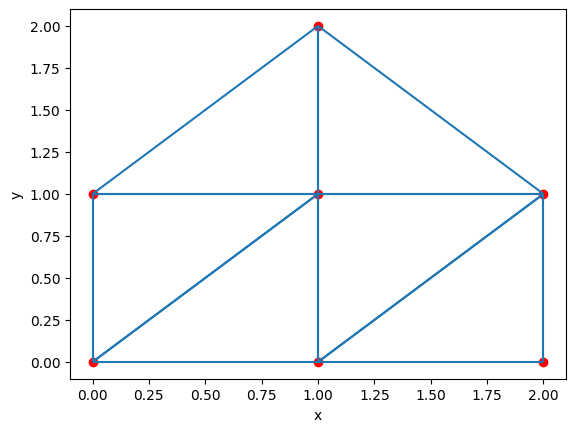

In [8]:
draw_mesh(points_siatka, triangles_siatka)

In [308]:
class HalfEdge:
    def __init__(self, origin : 'Vertex'=None, face : 'Face'=None, twin : 'HalfEdge'=None, next : 'HalfEdge'=None, prev : 'HalfEdge'=None):
        self.origin = origin

        self.face = face

        self.twin = twin

        self.next = next
        self.prev = prev

    def __eq__(self, other : 'HalfEdge'):
        # sprawdzam równość dwóch punktów na końcu krawędzi
        return self.origin == other.origin and self.next.origin == other.next.origin

    def __hash__(self):
        return hash(self.origin and self.next.origin)

In [10]:
class Vertex:
    def __init__(self, position : tuple[float], halfedge : HalfEdge = None, id : int = None):
        self.position = position

        # halfedge: dowolna półkrawędź wychodząca z tego wierzchołka
        self.halfedge = halfedge

        # id: indeks wierzchołka
        self.id = id

    def __add__(self, other):
        return (self.position[0] + other.position[0], self.position[1] + other.position[1])

    def __sub__(self, other):
        return (self.position[0] - other.position[0], self.position[1] - other.position[1])

    def __mul__(self, num):
        return (self.position[0] * num, self.position[1] * num)

    def __eq__(self, other):
        return self.id == other.id

    def __hash__(self):
        return hash(self.id)

In [11]:
class Face:
    def __init__(self, halfedge : HalfEdge=None):
        # halfedge: dowolna półkrawędź należąca do tej ściany (trójkąta)
        self.halfedge = halfedge

In [12]:
class HalfEdgeDataStructure:
    def __init__(self, points, triangles):
        self.vertices = [Vertex(pos, id=i) for i, pos in enumerate(points)]
        self.triangles = list(triangles)

        self.faces = []
        self.half_edges = []
        self.half_edges_dict = {}  # (u, v) -> HalfEdge u->v

        self._build_structure()
        self._build_boundary()

    def _pair_halfedge(self, u, v, edge):
        # szukamy przeciwnej półkrawędzi v->u
        t = self.half_edges_dict.get((v, u))
        if t is not None:
            edge.twin = t
            t.twin = edge
            del self.half_edges_dict[(v, u)]
        else:
            self.half_edges_dict[(u, v)] = edge

    def _build_structure(self):
        for a, b, c in self.triangles:
            face = Face()

            edge_0 = HalfEdge(origin=self.vertices[a], face=face)
            edge_1 = HalfEdge(origin=self.vertices[b], face=face)
            edge_2 = HalfEdge(origin=self.vertices[c], face=face)

            edge_0.next, edge_1.next, edge_2.next = edge_1, edge_2, edge_0
            edge_0.prev, edge_1.prev, edge_2.prev = edge_2, edge_0, edge_1

            face.halfedge = edge_0

            if self.vertices[a].halfedge is None:
                self.vertices[a].halfedge = edge_0
            if self.vertices[b].halfedge is None:
                self.vertices[b].halfedge = edge_1
            if self.vertices[c].halfedge is None:
                self.vertices[c].halfedge = edge_2

            # łączenie bliźniaczych krawędzi/dodawanie krawędzi do mapy
            self._pair_halfedge(a, b, edge_0)
            self._pair_halfedge(b, c, edge_1)
            self._pair_halfedge(c, a, edge_2)

            self.faces.append(face)
            self.half_edges.extend([edge_0, edge_1, edge_2])

    def _build_boundary(self):
        twinless_half_edges = list(self.half_edges_dict.values())

        new_boundary = []
        # tworzenie krawędzi na brzegach i łączenie ich z bliźniaczymi
        for edge in twinless_half_edges:
            u = edge.origin.id
            v = edge.next.origin.id

            b = HalfEdge(origin=self.vertices[v], face = None)
            b.twin = edge
            edge.twin = b

            new_boundary.append(b)

        # stworzenie mapy kolejnych połączeń dla krawędzi zewnętrznych
        incoming = {}
        for edge in twinless_half_edges:
            v = edge.next.origin.id
            incoming[v] = edge

        # łączenie następnych krawędzi zewnętrznych w pętlę
        for edge in twinless_half_edges:
            b = edge.twin
            u = edge.origin.id
            prev = incoming.get(u)
            b_next = prev.twin
            b.next = b_next
            b_next.prev = b

        self.half_edges.extend(new_boundary)

In [13]:
halfEdgeStructure = HalfEdgeDataStructure(points, triangles)

In [14]:
import math

def visualize_halfedge_structure(mesh : HalfEdgeDataStructure,
                                 draw_mesh_edges=True,
                                 draw_vertices=True,
                                 shrink=0.15,
                                 inward_offset=0.05):
    vis = Visualizer()

    def add(a, b): return (a[0] + b[0], a[1] + b[1])
    def sub(a, b): return (a[0] - b[0], a[1] - b[1])
    def mul(a, s): return (a[0] * s, a[1] * s)
    def dot(a, b): return a[0] * b[0] + a[1] * b[1]
    def length(v): return math.hypot(v[0], v[1])
    def norm(v):
        l = length(v)
        return (0.0, 0.0) if l == 0 else (v[0] / l, v[1] / l)

    # krawędzie triangulacji
    if draw_mesh_edges:
        verts_pos = [v.position for v in mesh.vertices]
        mesh_segments = []
        for a, b, c in mesh.triangles:
            mesh_segments.append((verts_pos[a], verts_pos[b]))
            mesh_segments.append((verts_pos[b], verts_pos[c]))
            mesh_segments.append((verts_pos[c], verts_pos[a]))
        vis.add_line_segment(mesh_segments)

    # wierzchołki
    if draw_vertices:
        vis.add_point([v.position for v in mesh.vertices], color='red')

    internal_segments, internal_tips = [], []
    boundary_segments, boundary_tips = [], []

    for he in mesh.half_edges:
        if he.next is None or he.origin is None:
            continue

        p0 = he.origin.position
        p1v = he.next.origin
        if p1v is None:
            continue
        p1 = p1v.position

        v = sub(p1, p0)
        L = length(v)
        if L == 0:
            continue

        # skrócenie odcinka
        start = add(p0, mul(v, shrink))
        end   = add(p0, mul(v, 1.0 - shrink))

        if he.face is None:
            # boundary: nie przesuwamy do wnętrza (bo nie ma ściany)
            boundary_segments.append((start, end))
            boundary_tips.append(end)
            continue

        # internal: przesuwamy do wnętrza trójkąta
        if he.prev is None:
            continue

        pa = he.origin.position
        pb = he.next.origin.position
        pc = he.prev.origin.position
        centroid = ((pa[0] + pb[0] + pc[0]) / 3.0, (pa[1] + pb[1] + pc[1]) / 3.0)

        n = norm((-v[1], v[0]))
        mid = ((p0[0] + p1[0]) / 2.0, (p0[1] + p1[1]) / 2.0)
        if dot(n, sub(centroid, mid)) < 0:
            n = (-n[0], -n[1])

        offset = inward_offset * L
        start_i = add(start, mul(n, offset))
        end_i   = add(end,   mul(n, offset))

        internal_segments.append((start_i, end_i))
        internal_tips.append(end_i)

    vis.add_line_segment(internal_segments)
    vis.add_point(internal_tips, color='blue')

    # boundary wyróżniamy kolorem końcówek
    vis.add_line_segment(boundary_segments)
    vis.add_point(boundary_tips, color='green')

    vis.show()


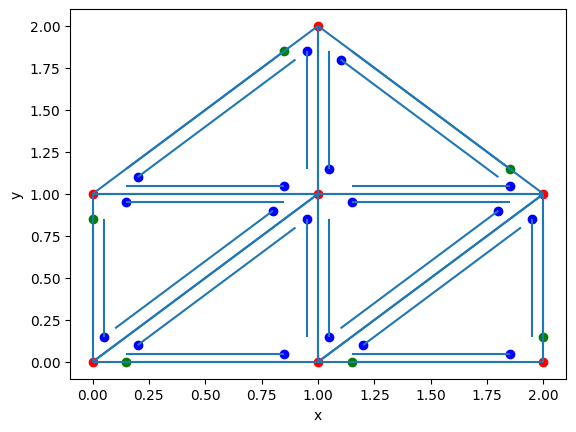

In [15]:
visualize_halfedge_structure(halfEdgeStructure)

In [16]:
big_mesh = load_mesh("big_siatka.txt")
big_mesh_structure = HalfEdgeDataStructure(big_mesh[0], big_mesh[1])

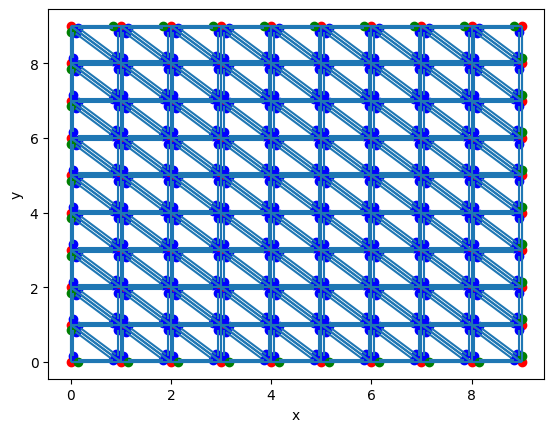

In [17]:
visualize_halfedge_structure(big_mesh_structure)

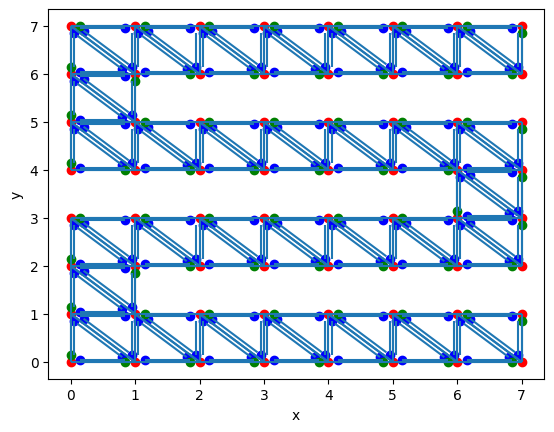

In [219]:
pasek_points, pasek_triangles = load_mesh('pasek.txt')
pasek_structure = HalfEdgeDataStructure(pasek_points, pasek_triangles)
visualize_halfedge_structure(pasek_structure)

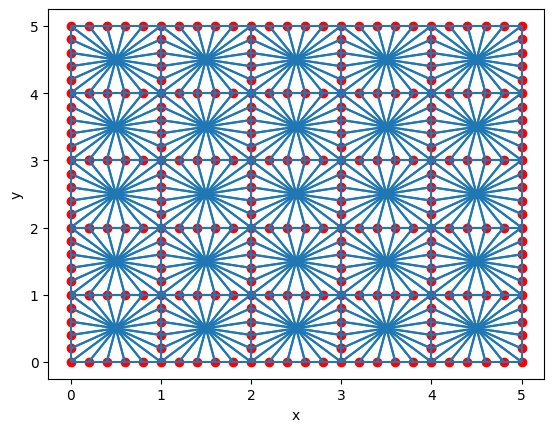

In [220]:
points_gwiazdy, triangles_gwiazdy = load_mesh('gwiazdy.txt')
gwiazdy_structure = HalfEdgeDataStructure(points_gwiazdy, triangles_gwiazdy)
# visualize_halfedge_structure(gwiazdy_structure)
draw_mesh(points_gwiazdy, triangles_gwiazdy)

# Operacje na siatce trójkątnej
### 1. Wyznaczanie otoczenia dla wybranego wierzchołka
### 2. Wyznaczanie otoczenia dla wybranego trójkąta
### 3. Przeglądanie incydentnych trójkątów od wybranego trójkąta w kierunku wybranego punktu

## Operacje dla list

In [18]:
def draw_triangle_list(vis : Visualizer, points, triangle, color='green'):
    vis.add_point([points[idx] for idx in triangle], color=color)
    vis.add_line_segment((points[triangle[0]], points[triangle[1]]), color=color)
    vis.add_line_segment((points[triangle[1]], points[triangle[2]]), color=color)
    vis.add_line_segment((points[triangle[2]], points[triangle[0]]), color=color)

In [67]:
def visit_point_list(points, triangles, point_idx, vis : Visualizer = None):
    visited = set()

    for triangle in triangles:
        if point_idx in triangle:
            visited.update(triangle)
            if vis is not None:
                draw_triangle_list(vis, points, triangle, color='red')

    return visited, vis

In [78]:
def find_surrounding_points_list(points, triangles, point_idx, layers=1):
    # budujemy graf: idx -> zbiór sąsiadów
    connections = {}

    for p1, p2, p3 in triangles:
        for p in [p1, p2, p3]:
            if p not in connections:
                connections[p] = set()
        connections[p1].add(p2)
        connections[p1].add(p3)
        connections[p2].add(p1)
        connections[p2].add(p3)
        connections[p3].add(p1)
        connections[p3].add(p2)

    output = [[point_idx]]

    # Odwiedzanie kolejnych warstw
    current_layer = {point_idx}
    all_visited = {point_idx}

    for _ in range(layers):
        output.append([])

        next_layer = set()
        for idx in current_layer:
            for new_idx in connections[idx]:
                if new_idx not in all_visited:
                    # Zbieramy punkty do kolejnej warstwy
                    next_layer.add(new_idx)
                    all_visited.add(new_idx)

        current_layer = next_layer
        for idx in current_layer:
            output[-1].append(idx)

    return output

In [79]:
find_surrounding_points_list(points, triangles, 1, 2)

[[1], [0, 2, 4, 5], [3, 6]]

In [59]:
def visualize_surrounding_points_list(points, triangles, point_idx, layers=1):
    vis = Visualizer()
    vis.add_point(points)

    # Odwiedzanie kolejnych warstw
    current_layer = {point_idx}
    all_visited = set()

    for _ in range(layers):
        next_layer = set()
        for idx in current_layer:
            if idx not in all_visited:
                new_visited, vis = visit_point_list(points, triangles, idx, vis)
                # Zbieramy punkty do kolejnej warstwy
                next_layer.update(new_visited)
                all_visited.add(idx)

        current_layer = next_layer - all_visited

    vis.add_point(points[point_idx], color='green')

    vis.show()

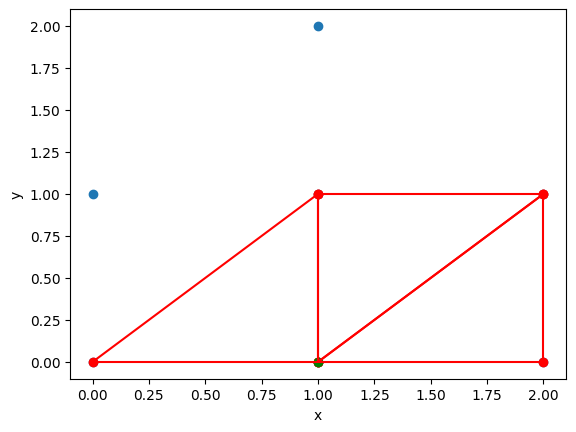

In [62]:
visualize_surrounding_points_list(points, triangles, 1)

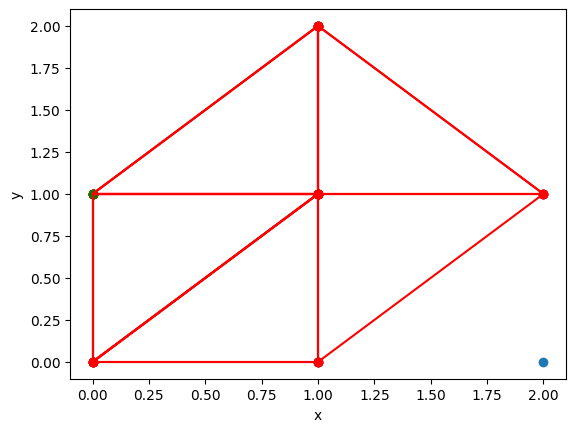

In [63]:
visualize_surrounding_points_list(points, triangles, 3, 2)

In [57]:
def visit_triangle_list(points, triangles, tri_idx, vis : Visualizer = None):
    triangle = triangles[tri_idx]
    # Wyciągamy krawędzie trójkąta (znormalizowane, by kolejność nie miała znaczenia)
    edges = []
    for i in range(3):
        p1, p2 = triangle[i], triangle[(i+1)%3]
        edges.append((p1, p2) if p1 < p2 else (p2, p1))

    if vis is not None:
        draw_triangle_list(vis, points, triangle, 'red')

    return edges, vis

In [58]:
def find_surrounding_triangle_list(points, triangles, start_tri_idx, layers=1):
    # Budujemy mapę krawędź -> lista indeksów trójkątów przyległych
    edge_to_tri = {}

    for idx, tri in enumerate(triangles):
        for i in range(3):
            p1, p2 = tri[i], tri[(i+1)%3]
            edge = (p1, p2) if p1 < p2 else (p2, p1)
            if edge not in edge_to_tri:
                edge_to_tri[edge] = []
            edge_to_tri[edge].append(idx)

    output = [[triangles[start_tri_idx]]]
    current_layer = {start_tri_idx}
    all_visited = {start_tri_idx}

    for _ in range(layers):
        next_layer = set()
        layer_triangles = []

        for tri_idx in current_layer:
            # Pobieramy krawędzie aktualnego trójkąta
            edges, _ = visit_triangle_list(points, triangles, tri_idx)

            for e in edges:
                neighbors = edge_to_tri.get(e, [])
                for n_idx in neighbors:
                    if n_idx not in all_visited:
                        all_visited.add(n_idx)
                        next_layer.add(n_idx)
                        layer_triangles.append(triangles[n_idx])

        output.append(layer_triangles)
        current_layer = next_layer

    return output

In [39]:
print(find_surrounding_triangle_list(points, triangles, 1, 2))

[[(0, 4, 3)], [(0, 1, 4), (3, 4, 6)], [(1, 5, 4), (4, 5, 6)]]


In [47]:
def visualize_surrounding_triangle_list(points, triangles, start_tri_idx, layers=1):
    vis = Visualizer()
    vis.add_point(points)

    # Budujemy mapę krawędź -> lista indeksów trójkątów przyległych
    edge_to_tri = {}

    for idx, tri in enumerate(triangles):
        for i in range(3):
            p1, p2 = tri[i], tri[(i+1)%3]
            edge = (p1, p2) if p1 < p2 else (p2, p1)
            if edge not in edge_to_tri:
                edge_to_tri[edge] = []
            edge_to_tri[edge].append(idx)


    current_layer = {start_tri_idx}
    all_visited = {start_tri_idx}

    for _ in range(layers):
        next_layer = set()
        for tri_idx in current_layer:
            # Sprawdzamy krawędzie trójkątów w bieżącej warstwie
            current_tri = triangles[tri_idx]
            for i in range(3):
                p1, p2 = current_tri[i], current_tri[(i+1)%3]
                edge = (p1, p2) if p1 < p2 else (p2, p1)

                # Pobieramy sąsiadów przez krawędź
                for n_idx in edge_to_tri.get(edge, []):
                    if n_idx not in all_visited:
                        all_visited.add(n_idx)
                        next_layer.add(n_idx)
                        draw_triangle_list(vis, points, triangles[n_idx], color='red')

        current_layer = next_layer

    draw_triangle_list(vis, points, triangles[start_tri_idx])

    vis.show()

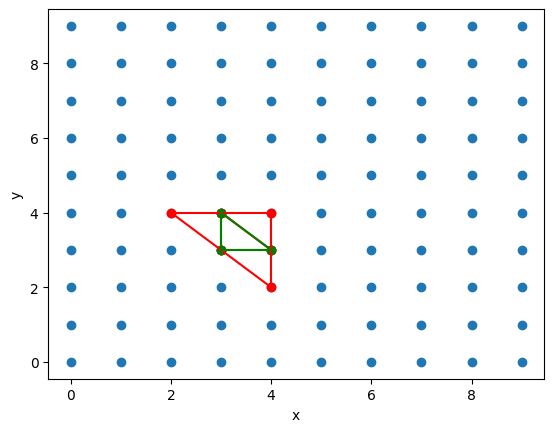

In [48]:
visualize_surrounding_triangle_list(big_mesh[0], big_mesh[1], 60)

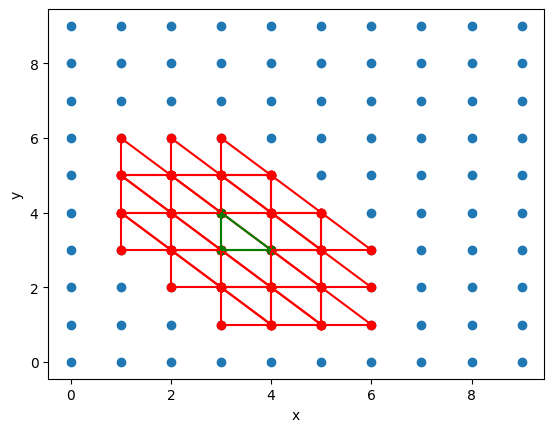

In [134]:
visualize_surrounding_triangle_list(big_mesh[0], big_mesh[1], 60, 2)

In [260]:
def orientation(a, b, c, eps=1e-12):
    # zwraca 1 jeśli p3 jest na prawo od prostej wyznaczonej przez p1, p2, w przeciwnym przypadku -1
    det = (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])
    if abs(det) <= eps:
        return 0
    return 1 if det > 0 else -1

In [270]:
def check_point_in_triangle_list(points, triangles, tri_idx, point):
    tri = triangles[tri_idx]
    p1, p2, p3 = points[tri[0]], points[tri[1]], points[tri[2]]

    o1 = orientation(p1, p2, point)
    o2 = orientation(p2, p3, point)
    o3 = orientation(p3, p1, point)
    return (o1 >= 0 and o2 >= 0 and o3 >= 0)

In [296]:
from collections import deque

def find_point_in_mesh_list(points, triangles, start_tri_idx, end_point):
    # Mapa trójkąt -> lista krawędzi skierowanych, tzn. idąc za indeksami końców krawędzi idziemy CCW
    tri_to_edges = {}
    # Mapa krawędź skierowana -> indeks trójkąta
    edge_to_tri = {}

    for idx, tri in enumerate(triangles):
        i1, i2, i3 = tri
        if orientation(points[i1], points[i2], points[i3]) < 0:
            # jeśli są CW, zamień dwa wierzchołki, żeby stały się CCW
            triangles[idx] = (i1, i3, i2)
        # dodajemy krawędzie w kolejności CCW: (a,b), (b,c), (c,a)
        a, b, c = triangles[idx]
        edges = [(a, b), (b, c), (c, a)]
        tri_to_edges[idx] = edges
        for edge in edges:
            edge_to_tri[edge] = idx

    queue = deque()
    queue.append(start_tri_idx)
    visited_triangles = set()

    while queue:
        curr_triangle_idx = queue.popleft()
        if curr_triangle_idx in visited_triangles:
            continue
        visited_triangles.add(curr_triangle_idx)

        if check_point_in_triangle_list(points, triangles, curr_triangle_idx, end_point):
            return curr_triangle_idx

        for edge in tri_to_edges[curr_triangle_idx]:
            # krawędź przeciwna do obecnej prowadzi do kolejnego trójkąta
            # jeśli istnieje to ma ona swój trójkąt
            next_edge = (edge[1], edge[0])
            if next_edge in edge_to_tri:
                queue.append(edge_to_tri[next_edge])

    return -1

In [305]:
def visualize_point_in_mesh_list(points, triangles, start_tri_idx, end_point):
    vis = Visualizer()
    vis.add_point(points)

    # Mapa trójkąt -> lista krawędzi skierowanych, tzn. idąc za indeksami końców krawędzi idziemy CCW
    tri_to_edges = {}
    # Mapa krawędź skierowana -> indeks trójkąta
    edge_to_tri = {}

    for idx, tri in enumerate(triangles):
        i1, i2, i3 = tri
        if orientation(points[i1], points[i2], points[i3]) < 0:
            # jeśli są CW, zamień dwa wierzchołki, żeby stały się CCW
            triangles[idx] = (i1, i3, i2)
        # dodajemy krawędzie w kolejności CCW: (a,b), (b,c), (c,a)
        a, b, c = triangles[idx]
        edges = [(a, b), (b, c), (c, a)]
        tri_to_edges[idx] = edges
        for edge in edges:
            edge_to_tri[edge] = idx

    queue = deque([start_tri_idx])
    visited_triangles = set()

    while queue:
        curr_triangle_idx = queue.popleft()
        if curr_triangle_idx in visited_triangles:
            continue
        visited_triangles.add(curr_triangle_idx)

        draw_triangle_list(vis, points, triangles[curr_triangle_idx], color='red')

        if check_point_in_triangle_list(points, triangles, curr_triangle_idx, end_point):
            break

        for edge in tri_to_edges[curr_triangle_idx]:
            # krawędź przeciwna do obecnej prowadzi do kolejnego trójkąta
            # jeśli istnieje to ma ona swój trójkąt
            next_edge = (edge[1], edge[0])
            if next_edge in edge_to_tri:
                queue.append(edge_to_tri[next_edge])

    draw_triangle_list(vis, points, triangles[start_tri_idx])
    vis.add_point(end_point, color='green')

    vis.show()

In [297]:
print(find_point_in_mesh_list(points, triangles, 0, (1.25, 1.25)))

5


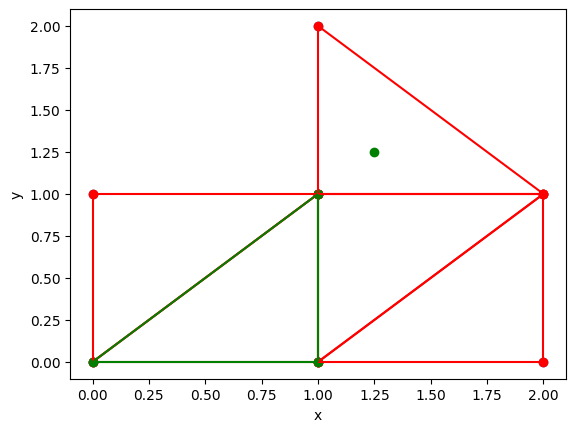

In [301]:
visualize_point_in_mesh_list(points, triangles, 0, (1.25, 1.25))

In [298]:
print(find_point_in_mesh_list(big_mesh[0], big_mesh[1], 0, (2.5, 1.25)))

22


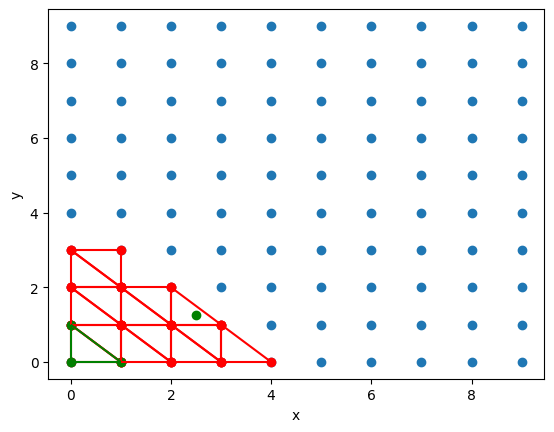

In [302]:
visualize_point_in_mesh_list(big_mesh[0], big_mesh[1], 0, (2.5, 1.25))

In [303]:
print(find_point_in_mesh_list(pasek_points, pasek_triangles, 13, (6.5, 6.75)))

61


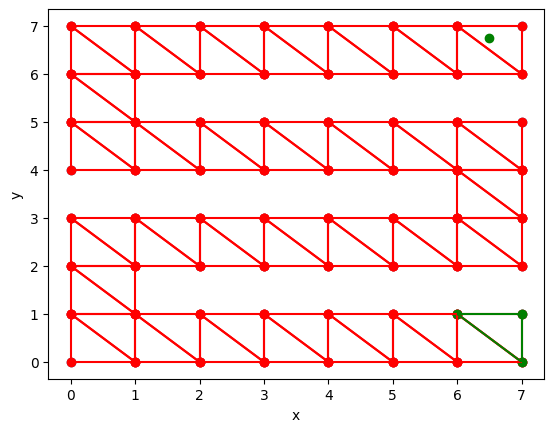

In [304]:
visualize_point_in_mesh_list(pasek_points, pasek_triangles, 13, (6.5, 6.75))

## Operacje dla struktury Half Edge Data Structure

In [102]:
def draw_triangle_structure(face_edges: list[HalfEdge | None], vis: Visualizer, color='green'):
    vis.add_point([edge.origin.position for edge in face_edges], color=color)
    vis.add_line_segment((face_edges[0].origin.position, face_edges[1].origin.position), color=color)
    vis.add_line_segment((face_edges[1].origin.position, face_edges[2].origin.position), color=color)
    vis.add_line_segment((face_edges[2].origin.position, face_edges[0].origin.position), color=color)

In [103]:
def visit_point_structure(point: Vertex, vis: Visualizer | None):
    visited = set()
    visited.add(point)

    if vis is not None:
        vis.add_point(point.position, color='red')

    curr_edge = point.halfedge
    # przechodzimy po wszystkich ścianach wokół punktu
    while curr_edge is not None:
        if curr_edge.face is not None:
            # Rysujemy wszystkie 3 boki trójkąta, do którego należy curr
            edges_in_face = [curr_edge, curr_edge.next, curr_edge.prev]
            visited.update([edge.origin for edge in edges_in_face])
            if vis is not None:
                draw_triangle_structure(edges_in_face, vis, color='red')

        # sprawdzamy, czy istnieje kolejna ściana
        curr_edge = curr_edge.twin.next if curr_edge.twin else None
        # sprawdziliśmy wszystko
        if curr_edge == point.halfedge:
            break

    return visited, vis

In [104]:
def find_surrounding_point_structure(structure: HalfEdgeDataStructure, vertex : Vertex, layers=1):
    if vertex not in structure.vertices:
        raise Exception('No such vertex')

    # Zawiera listy indeksów punktów w kolejnych warstwach, lista 0 - punkt startowy, lista 1 - pierwsza warstwa, itd.
    output = [[vertex.id]]

    # Odwiedzanie kolejnych warstw
    current_layer = {vertex}
    all_visited = {vertex}

    for i in range(layers):
        output.append([])

        next_layer = set()
        for point in current_layer:
            neighbours, _ = visit_point_structure(point, None)
            for new_point in neighbours:
                if new_point not in all_visited:
                    # Zbieramy punkty do kolejnej warstwy
                    next_layer.add(new_point)
                    all_visited.add(new_point)

        current_layer = next_layer
        for point in current_layer:
            output[i+1].append(point.id)

    return output

In [105]:
print(find_surrounding_point_structure(halfEdgeStructure, halfEdgeStructure.vertices[1], 2))

[[1], [0, 2, 4, 5], [3, 6]]


In [106]:
def visualize_surrounding_point_structure(structure: HalfEdgeDataStructure, vertex : Vertex, layers=1):
    vis = Visualizer()
    vis.add_point([point.position for point in structure.vertices])

    if vertex not in structure.vertices:
        raise Exception('No such vertex')

    # Odwiedzanie kolejnych warstw
    current_layer = {vertex}
    all_visited = set()

    for _ in range(layers):
        next_layer = set()
        for point in current_layer:
            if point not in all_visited:
                new_visited, vis = visit_point_structure(point, vis)
                # Zbieramy punkty do kolejnej warstwy
                next_layer.update(new_visited)
                all_visited.add(point)

        current_layer = next_layer - all_visited

    vis.add_point(vertex.position, color='green')

    vis.show()

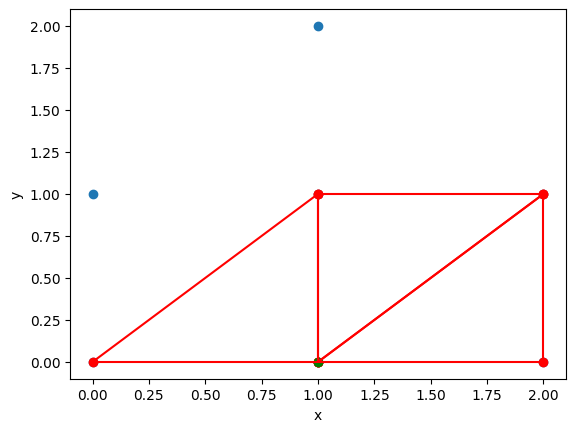

In [107]:
visualize_surrounding_point_structure(halfEdgeStructure, halfEdgeStructure.vertices[1])

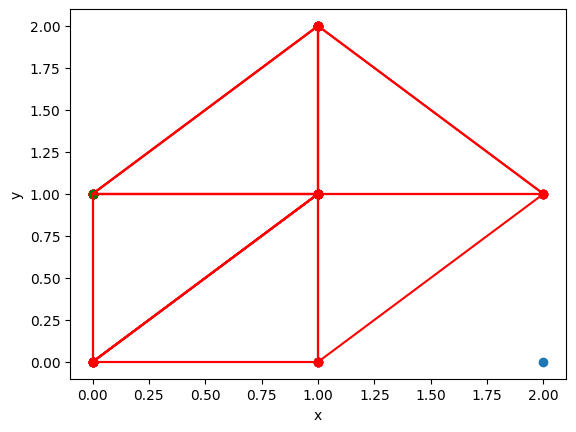

In [108]:
visualize_surrounding_point_structure(halfEdgeStructure, halfEdgeStructure.vertices[3], 2)

In [109]:
# "odwiedza" trójkąt przyległy do zadanej krawędzi
def visit_edge_structure(edge: HalfEdge, vis: Visualizer | None):
    visited = [edge, edge.next, edge.prev]
    if vis is not None:
        draw_triangle_structure(visited, vis, 'red')

    return visited, vis

In [306]:
def find_surrounding_triangle_structure(structure: HalfEdgeDataStructure, face : Face, layers=1):
    if face not in structure.faces:
        raise Exception('No such face')

    edge_in_face = face.halfedge
    face_edges = [edge_in_face, edge_in_face.next, edge_in_face.prev]

    output = [[edge.origin.id for edge in face_edges]]

    # Śledzimy odwiedzone ściany, by nie przetwarzać tego samego trójkąta dwa razy
    all_visited_faces = {face}
    current_layer = set(face_edges)

    for i in range(layers):
        output.append([])

        next_layer = set()
        for edge in current_layer:
            neighbor = edge.twin
            if neighbor and neighbor.face and neighbor.face not in all_visited_faces:
                all_visited_faces.add(neighbor.face)
                new_edges, _ = visit_edge_structure(neighbor, None)

                # Zbieramy krawędzie do kolejnej warstwy
                next_layer.update(new_edges)
                output[i+1].append([edge.origin.id for edge in new_edges])

        current_layer = next_layer

    return output

In [307]:
print(find_surrounding_triangle_structure(halfEdgeStructure, halfEdgeStructure.faces[1], 2))

[[0, 4, 3], [[3, 4, 6], [4, 0, 1]], [[4, 1, 5], [6, 4, 5]]]


In [112]:
def visualize_surrounding_triangle_structure(structure: HalfEdgeDataStructure, face : Face, layers=1):
    vis = Visualizer()
    vis.add_point([point.position for point in structure.vertices])

    if face not in structure.faces:
        raise Exception('No such face')

    edge_in_face = face.halfedge
    face_edges = [edge_in_face, edge_in_face.next, edge_in_face.prev]

    # Śledzimy odwiedzone ściany, by nie przetwarzać tego samego trójkąta dwa razy
    all_visited_faces = {face}
    current_layer = set(face_edges)

    for _ in range(layers):
        next_layer = set()
        for edge in current_layer:
            # Sprawdzamy, czy za krawędzią jest sąsiad i czy jego ściana nie była już odwiedzona
            neighbor = edge.twin
            if neighbor is not None and neighbor.face is not None and neighbor.face not in all_visited_faces:
                new_visited, vis = visit_edge_structure(neighbor, vis)

                all_visited_faces.add(neighbor.face)
                next_layer.update(new_visited)

        current_layer = next_layer

    draw_triangle_structure(face_edges, vis)

    vis.show()

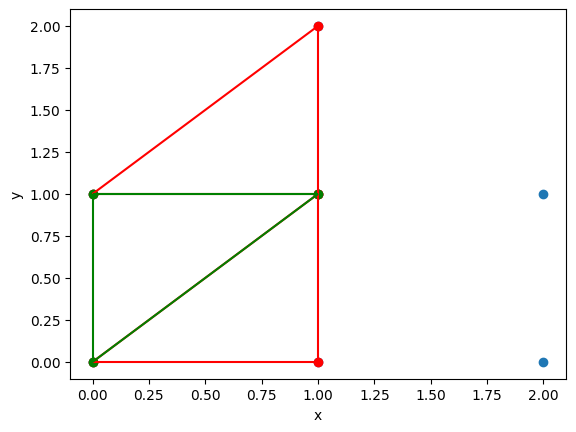

In [113]:
visualize_surrounding_triangle_structure(halfEdgeStructure, halfEdgeStructure.faces[1])

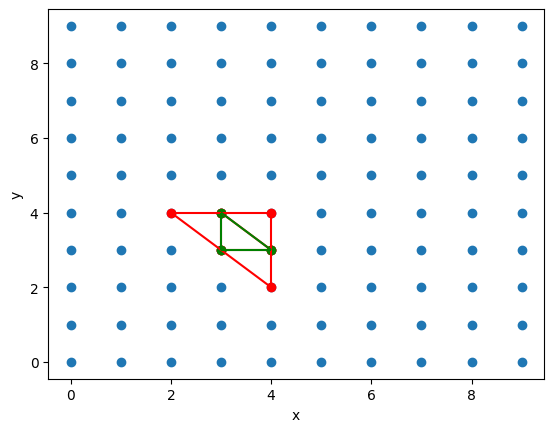

In [114]:
visualize_surrounding_triangle_structure(big_mesh_structure, big_mesh_structure.faces[60])

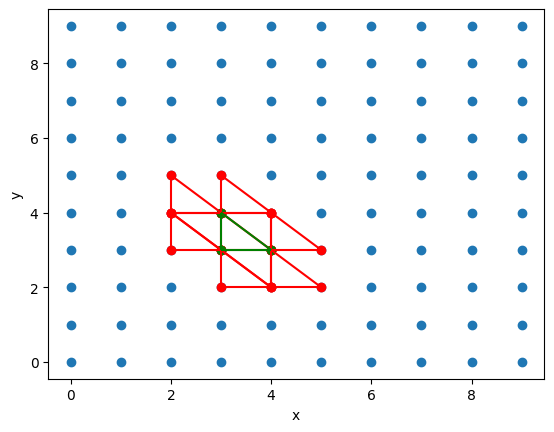

In [115]:
visualize_surrounding_triangle_structure(big_mesh_structure, big_mesh_structure.faces[60], 2)

In [116]:
def find_point_in_mesh_structure(structure : HalfEdgeDataStructure, start_tri_idx, end_point):


    return